## Imports

In [84]:
import pandas as pd
import pandapower as pp
import pandapower.converter.matpower as pc
import pandapower.plotting as pplot
import pandapower.estimation as est
import networkx as nx
import matplotlib.pyplot as plt
import warnings
import numpy as np
import os
import pprint
import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy.sparse as sp
import pickle
import re
import random

from torch_geometric.utils import from_networkx, to_dense_adj, negative_sampling
from torch_geometric.nn import GCNConv, GATConv, NNConv
from scipy.sparse import csr_matrix
from pathlib import Path
from sklearn.cluster import KMeans, MeanShift, estimate_bandwidth
from pandapower.estimation.algorithm.matrix_base import BaseAlgebra
from pandapower.estimation.ppc_conversion import ExtendedPPCI
from collections import deque
from pandapower.estimation.ppc_conversion import pp2eppci

warnings.simplefilter(action="ignore", category=pd.errors.SettingWithCopyWarning)
np.set_printoptions(threshold=np.inf)

## Network Loading

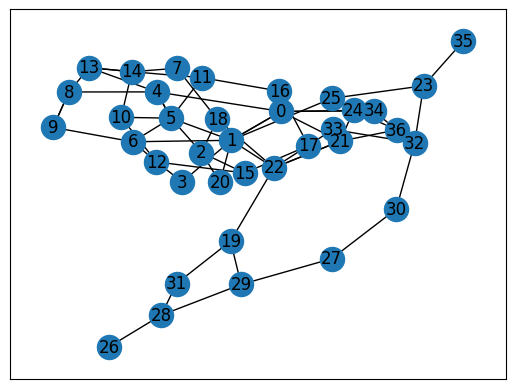

There are 37 buses.
There are 64 lines.
There are 0 measurements.


In [85]:
def reset_network(gridname="Hawaii40_20231026.m"):
    global net
    net = pc.from_mpc(f"grids/{gridname}",
                       f_hz=60,
                       check_costs=False)
    
    dup_mask = net.line.duplicated(subset=['from_bus', 'to_bus'], keep='first')
    dup_lines = net.line[dup_mask].index.tolist()
    if len(dup_lines) > 0:
        pp.toolbox.drop_lines(net, dup_lines)

    dup_mask = net.impedance.duplicated(subset=['from_bus', 'to_bus'], keep='first')
    dup_impedances = net.impedance[dup_mask].index.tolist()
    if len(dup_impedances) > 0:
        pp.toolbox.drop_elements(net, element_type="impedance", element_index=dup_impedances)


    if len(net.impedance.index) > 0:
        for impedance in net.impedance.index:
            line = np.random.choice(net.line.index)
            pp.create_line_from_parameters(net, from_bus=net.impedance.from_bus[impedance], to_bus=net.impedance.to_bus[impedance], length_km=net.line.length_km[line], r_ohm_per_km=net.line.r_ohm_per_km[line], x_ohm_per_km=net.line.x_ohm_per_km[line], c_nf_per_km=net.line.c_nf_per_km[line], max_i_ka=net.line.max_i_ka[line])

    pp.create_ext_grid(net, bus=net.bus.index[0])
    pp.runpp(net)
    
    return net

def check_network_parameters(net):
    print(f"There are {len(net.bus.index)} buses.")
    print(f"There are {len(net.line.index) + len(net.impedance.index)} lines.")
    print(f"There are {len(net.measurement)} measurements.")

net = reset_network()

graph = pplot.create_nxgraph(net)
nx.draw_networkx(graph, with_labels=True)
plt.show()

check_network_parameters(net)    

## Dataset Generation

In [86]:
LINEFLOW_PROB = [.2, .25, .3, .35, .4]
VOLTAGE_PROB = [.1, .15, .2, .25, .3]

def check_duplicates(path):
    to_check = []
    try:
        for root, _, files in os.walk(path):
            for file in sorted(files):
                filepath = os.path.join(root, file)
                with open(filepath, "rb") as f:
                    to_check.append(f.read())

        set_check = set(to_check)
        if len(to_check) != len(set_check):
            print("There are duplicates.")
        else:
            print("There are no duplicates.")

    except FileNotFoundError:
        print(f"The file {path} does not exist.")

def generate_measurement_graphs(configurations, savepath, grid="Hawaii40_20231026.m"):
    for lineflow in LINEFLOW_PROB:
        for voltage in VOLTAGE_PROB:
            for conf in range(configurations):
                net = reset_network(gridname=grid)

                buses = net.bus.index.to_list()
                lines = net.line.index.to_list()
                
                lineflow_hits = round(len(lines) * lineflow)
                voltage_hits = round(len(buses) * voltage)

                for _ in range(int(lineflow_hits)):
                    line = np.random.choice(lines)
                    lines.remove(line)

                    side = np.random.choice(["from", "to"])

                    for meas_type in ['p', 'q']:
                        value = value = net.res_line[f"p_{side}_mw" if meas_type == "p" else f"q_{side}_mvar"][line]
                        pp.create_measurement(net, meas_type=meas_type, element_type="line",
                          side=side, value=value, std_dev=0.03, element=line)
                buses = net.bus.index.to_list()
                
                for _ in range(int(voltage_hits)):
                    bus = np.random.choice(buses)
                    pp.create_measurement(net, meas_type="p", element_type="bus",
                          value=net.res_bus.p_mw[bus], std_dev=0.03, element=bus)
                    pp.create_measurement(net, meas_type="q", element_type="bus",
                          value=net.res_bus.q_mvar[bus], std_dev=0.03, element=bus)
                    buses.remove(bus)

                net, _, _ = pp2eppci(net)

                def strip_prefix(s):
                    return str(s)[2:] if len(str(s)) > 2 else str(s)

                os.makedirs(f"{savepath}/pkls", exist_ok=True)
                os.makedirs(f"{savepath}/jsons", exist_ok=True)
                pklfile = os.path.join(f"{savepath}/pkls", f"{strip_prefix(lineflow)}_{strip_prefix(voltage)}_conf{conf}.pkl")
                jsonfile = os.path.join(f"{savepath}/jsons", f"{strip_prefix(lineflow)}_{strip_prefix(voltage)}_conf{conf}.json")

                with open(jsonfile, "w") as _:
                    pp.to_json(net, jsonfile)

                graph = pplot.create_nxgraph(net, include_lines=True, include_impedances=False)

                node_features = []
                edge_features = []

                for node in graph.nodes:
                    value = np.float32(0)
                    meas_type = ""
                    degree = graph.degree(node)
                    is_measured = False

                    node_data = net.measurement[(net.measurement.element_type == "bus") & (net.measurement.element == node)]

                    if node_data.shape[0] >= 1:
                        measurement = node_data.iloc[0]
                        value = measurement.value
                        meas_type = measurement.measurement_type
                        is_measured = True

                    node_features.append([value, meas_type, degree, is_measured])

                node_features = np.array(node_features, dtype=object)
                node_features_names = ["value", "type", "degree", "is_measured"]

                for j, name in enumerate(node_features_names):
                    attrs = {i: node_features[i, j] for i in range(len(node_features))}
                    nx.set_node_attributes(graph, attrs, name=name)

                for edge in graph.edges(keys=True):
                    value = np.float32(0)
                    meas_type = ""
                    pole = 0
                    is_measured = False

                    line_index = edge[2][0]

                    edge_data = net.measurement[((net.measurement.element_type == "line") & (net.measurement.element == line_index))]

                    if edge_data.shape[0] >= 1:
                        measurement = edge_data.iloc[0]
                        meas_type = measurement.measurement_type
                        pole = 1 if measurement.side == "from" else 2
                        is_measured = True
                    
                    edge_features.append([value, meas_type, pole, is_measured])

                edge_features = np.array(edge_features, dtype=object) 
                
                edgefeature_names = ["value", "type", "pole", "is_measured"]
                edges = list(graph.edges)

                for j, name in enumerate(edgefeature_names):
                    attrs = {(edges[i][0], edges[i][1], edges[i][2]): edge_features[i, j] for i in range(len(edges))}
                    nx.set_edge_attributes(graph, attrs, name=name)

                with open(pklfile, "wb") as f:
                    pickle.dump(graph, f)


In [87]:
# generate_measurement_graphs(configurations=10, savepath="datasets/complete_dataset")
check_duplicates(path="datasets/complete_dataset")

There are no duplicates.


In [88]:
# QUICK SANITY CHECK

for filename in os.listdir("datasets/topological_dataset/pkls"):
    print(filename)
    with open(f"datasets/topological_dataset/pkls/{filename}", "rb") as f:
        numbers = re.findall(r'\d+', filename)
        net = pickle.load(f)
        no_attrs = 0
        for _, attrs in net.nodes(data=True):
            if attrs["is_measured"]:
                no_attrs += 1
        print(f"{no_attrs}")
        print(float(numbers[1])/10.0 * 37)
        print("-"*30)

6_9_conf4.pkl
33
33.300000000000004
------------------------------
6_9_conf1.pkl
33
33.300000000000004
------------------------------
6_7_conf0.pkl
25
25.9
------------------------------
5_9_conf3.pkl
33
33.300000000000004
------------------------------
8_8_conf2.pkl
29
29.6
------------------------------
7_7_conf0.pkl
25
25.9
------------------------------
5_9_conf1.pkl
33
33.300000000000004
------------------------------
4_8_conf0.pkl
29
29.6
------------------------------
4_7_conf3.pkl
25
25.9
------------------------------
7_9_conf3.pkl
33
33.300000000000004
------------------------------
5_8_conf4.pkl
29
29.6
------------------------------
6_8_conf3.pkl
29
29.6
------------------------------
7_6_conf3.pkl
22
22.2
------------------------------
6_8_conf0.pkl
29
29.6
------------------------------
5_9_conf2.pkl
33
33.300000000000004
------------------------------
6_6_conf3.pkl
22
22.2
------------------------------
5_7_conf1.pkl
25
25.9
------------------------------
5_8_conf3.pkl
2

## Topological Observability Algorithm

In [89]:
def prepare_merged_graph(path: str):

    def update_measurements(lines, u, v):
        new_list = []

        for (x, y) in lines:
            new_x = u if x == v else x
            new_y = u if y == v else y
            if new_x != new_y:
                new_list.append((new_x, new_y))

        return new_list
    
    lines = set()
    buses =set()
    
    net = pp.from_json(path)
        
    for measurement in net.measurement.index:
            if net.measurement.element_type[measurement] == "line":
                line = net.measurement.element[measurement]
                from_bus = net.line.from_bus[line]
                to_bus = net.line.to_bus[line]
                lines.add((np.int64(from_bus), np.int64(to_bus)))

            if net.measurement.element_type[measurement] == "bus":
                bus = net.measurement.element[measurement]
                buses.add(np.int64(bus))

    graph = pplot.create_nxgraph(net)
    graph = nx.Graph(graph)
    merges = {key: [] for key in graph.nodes}
    new_graph = graph.copy()

    while lines:
        (u, v) = lines.pop()
        (u, v) = (min(u, v), max(u, v))
        
        merges[u].extend([v])
        try:
            merges[u].extend(merges[v])
            merges.pop(v)
        except KeyError:
            pass

        new_graph = nx.contracted_nodes(new_graph, u, v, self_loops=False)
        lines = update_measurements(lines, u, v)

    return new_graph, buses, merges


In [90]:
def get_loop(forest, u, v):
    try:
        path = nx.shortest_path(forest, u, v)
        return [(min(u, v), max(u, v)) for u, v in zip(path[:-1], path[1:])]
    except nx.NetworkXNoPath:
        return None
    
def get_merge(merges, bus):
        for superbus, buses in merges.items():
            if len(buses) == 0:
                continue
            if bus in buses:
                return superbus
        return bus

def augmented_injections(reference, buses, merges): 
    def find_augmenting_sequence(forest, bus, assigned):
        # visited = set()
        queue = deque()

        for neighbor in reference.neighbors(bus):
            edge = (min(bus, neighbor), max(bus, neighbor))
            # if edge in visited:
            #     continue
            # visited.add(edge)

            loop_edges = get_loop(forest, bus, neighbor)
            if loop_edges is not None:
                sim_forest = forest.copy()
                sim_forest.add_edge(*edge)
                queue.append((edge, [edge], sim_forest, {edge}))
            else:
                return [edge]

        while queue:
            free_edge, path, sim_forest, visited = queue.popleft()
            u, v = free_edge

            loop_edges = get_loop(sim_forest, u, v)

            if loop_edges is None:
                return path

            for loop_edge in loop_edges:
                loop_edge = (min(loop_edge), max(loop_edge))
                if loop_edge not in assigned:
                    continue

                assigned_bus = assigned.get(loop_edge)

                for neighbor in reference.neighbors(get_merge(merges, assigned_bus)):
                    candidate = (min(get_merge(merges, assigned_bus), neighbor), max(get_merge(merges, assigned_bus), neighbor))
                    if candidate == loop_edge:
                        continue
                    if sim_forest.has_edge(*candidate):
                        continue
                    if candidate in visited:
                        continue

                    new_visited = visited.copy()
                    new_visited.add(candidate)

                    new_sim = sim_forest.copy()
                    new_sim.remove_edge(*loop_edge)

                    u2, v2 = candidate
                    new_loop_edges = get_loop(new_sim, u2, v2)
                    if new_loop_edges is None:
                        return path + [loop_edge, candidate]
                    else:
                        new_sim.add_edge(*candidate)
                        new_path = path + [loop_edge, candidate]
                        queue.append((candidate, new_path, new_sim, new_visited))

        return None

    forest = nx.Graph()
    forest.add_nodes_from(reference.nodes)

    assigned = {}

    for bus in buses:
        neighbors = list(reference.neighbors(get_merge(merges, bus)))
        assigned_directly = False

        for node in neighbors:
            edge = (min(get_merge(merges, bus), node), max(get_merge(merges, bus), node))
            if get_loop(forest, get_merge(merges, bus), node) is None:
                    forest.add_edge(get_merge(merges, bus), node)
                    assigned[edge] = bus
                    assigned_directly = True
                    break

        if not assigned_directly:
            seq = find_augmenting_sequence(forest, get_merge(merges, bus), assigned)
            if seq is not None:
                for i, edge in enumerate(seq):
                    if i % 2 == 0:
                        forest.add_edge(*edge)
                    else:
                        forest.remove_edge(*edge)

                for i in range(1, len(seq), 2):
                    removed_edge = seq[i]
                    old_owner = assigned.pop(removed_edge)
                    new_edge = seq[i + 1]
                    assigned[new_edge] = old_owner

                assigned[seq[0]] = bus

    return forest, assigned

In [91]:
def recreate_graph(graph: nx.Graph, merges):
        # observable_injections = {node for node in graph.nodes() if graph.degree(node) > 0}
        # observable_flows = {node for node in merges.keys() if len(merges[node]) > 0}
        # observable_nodes = observable_injections.union(observable_flows)
        no_nodes = 0
        for superbus, buses in merges.items():
            for bus in buses:
                if bus not in graph.nodes:
                    graph.add_node(np.int64(bus))
                    no_nodes += 1
                graph.add_edge(np.int64(bus), np.int64(superbus))
        # print(f"Number of nodes added: {no_nodes}")
        return graph

def remove_unusable_injections(maximal_forest, assigned, old_graph, merges):
        changed = True

        while changed:
            changed = False
            for edge, bus in list(assigned.items()):
                superbus = get_merge(merges, bus)
                unusable = False

                for neighbor in old_graph.neighbors(superbus):
                    neighbor_super = get_merge(merges, neighbor)
                    if neighbor_super == superbus:
                        continue
                    if maximal_forest.has_edge(superbus, neighbor_super):
                        continue
                    if get_loop(maximal_forest, superbus, neighbor_super) is not None:
                        continue

                    unusable = True
                    break
                
                if unusable:
                    if maximal_forest.has_edge(*edge):
                        maximal_forest.remove_edge(*edge)
                    assigned.pop(edge)
                    changed = True
                    break

        return maximal_forest.copy(), assigned

In [92]:
def get_island_labels(json_path):
    graph, buses, merges = prepare_merged_graph(json_path)
    # print(f"Number of nodes in merged graph: {len(graph.nodes())}")
    forest, assigned = augmented_injections(graph, buses, merges)
    maximal_forest, assigned = remove_unusable_injections(forest, assigned, graph, merges)
    # print(f"Number of nodes in maximal forest: {len(maximal_forest.nodes())}")
    maximal_forest = recreate_graph(maximal_forest, merges)
    # print(f"Number of nodes in maximal forest after adding nodes: {len(maximal_forest.nodes())}")
    shrunk_forest, assigned = remove_unusable_injections(maximal_forest, assigned, graph, merges)

    components = [c for c in nx.connected_components(shrunk_forest) if len(c) >= 2]
    obs_nodes = set().union(*components)
    unobs_nodes = set(maximal_forest.nodes()) - obs_nodes

    for node in unobs_nodes:
        shrunk_forest.remove_node(node)

    island_labels = {node: i for i, component in enumerate(components) for node in component}
    # print(f"BEFORE island labels have {len(island_labels)} nodes")
    for node in unobs_nodes:
        island_labels[node] = -1
    # print(f"AFTER island labels have {len(island_labels)} nodes")

    # print(sorted(island_labels))

    ret_val = torch.tensor(
        [island_labels.get(node, -1) for node in maximal_forest.nodes()],
        dtype=torch.long
    )
    return ret_val 

In [93]:
def get_observable_islands(path):
    json_dir = os.path.join(path, "jsons")
    # islands_dir = os.path.join(path, "islands")
    obs_dir = os.path.join(path, "islands")
    res_dir = os.path.join(path, "baseline_results")
    pkl_dir = os.path.join(path, "pkls")
    if not os.path.exists(pkl_dir):
        print(f"The directory {pkl_dir} does not exist.")
        return
    # if not os.path.exists(islands_dir):
    #         os.makedirs(islands_dir)
    if not os.path.exists(obs_dir):
            os.makedirs(obs_dir)
    if not os.path.exists(res_dir):
            os.makedirs(res_dir)

    for filename in os.listdir(json_dir):
        file_path = os.path.join(json_dir, filename)
        # figure_path = os.path.join(islands_dir, filename.replace(".json", ".png"))
        obs_path = os.path.join(obs_dir, filename.replace(".json", "_obs.png"))
        res_path = os.path.join(res_dir, filename.replace(".json", "_obs.json"))
        pkl_path = os.path.join(pkl_dir, filename.replace(".json", ".pkl"))
        if os.path.exists(obs_path) and os.path.exists(res_path):
            print(f"{filename} already processed.")
            print("-"*20)
            continue

        graph, buses, merges = prepare_merged_graph(file_path)
        net = pp.from_json(file_path)
        old_graph = pplot.create_nxgraph(net)
        old_graph = nx.Graph(old_graph)

        maximal_forest, assigned = augmented_injections(graph, buses, merges)
        # nx.draw(maximal_forest, with_labels=True)
        # plt.show()
        # plt.close()
        # print(f"maximal: {len(maximal_forest.nodes())}")
        
        maximal_forest = recreate_graph(maximal_forest, merges)
        # nx.draw(maximal_forest, with_labels=True)
        # plt.show()
        # plt.close()
        # print(f"recreated: {len(maximal_forest.nodes())}")
        
        shrunk_forest, assigned = remove_unusable_injections(maximal_forest, assigned, old_graph, merges)
        if len(shrunk_forest.nodes()) != 37:
            print(f"Shrunk forest has {len(shrunk_forest.nodes())} nodes, expected 37., filename {filename}.")
        # maximal_forest, assigned = remove_unusable_injections(maximal_forest, assigned, old_graph, merges)

        components = [c for c in nx.connected_components(shrunk_forest) if len(c) >= 2]
        obs_nodes = set().union(*components)
        unobs_nodes = set(graph.nodes()) - obs_nodes
        pp.toolbox.drop_buses(net, list(unobs_nodes))
        pp.toolbox.drop_inactive_elements(net)  
        with open(res_path, "w") as _:
            pp.to_json(net, res_path)

        # print(type(shrunk_forest))
        # print(shrunk_forest.adjacency())

        island_labels = {node: i for i, component in enumerate(components) for node in component}

        if len(components) > 0:
            node_colors = ["green" if node in obs_nodes else "red" for node in shrunk_forest.nodes()]
            nx.draw(shrunk_forest, with_labels=True, node_color=node_colors)
            plt.savefig(obs_path)
            plt.close()

        max_size = 0
        for component in components:
            if len(component) > max_size:
                max_size = len(component)
        with open(os.path.join(path, "islands.txt"), "a") as f:
            f.write(f"{filename}: {len(components)} islands, size: {max_size}\n")
        print(f"{filename}: {len(components)} islands.")
        print("-"*20)

In [94]:
# get_observable_islands('datasets/complete_dataset')

In [95]:
with open('datasets/topological_dataset/pkls/4_7_conf0.pkl', "rb") as f:
    graph = pickle.load(f)

for node, args in graph.nodes(data=True):
    print(node, args)

for u, v, args in graph.edges(data=True):
    print(u, v, args)

0 {'value': np.float64(0.998834811921439), 'type': 'v', 'degree': 5, 'is_measured': True}
4 {'value': np.float64(1.0), 'type': 'v', 'degree': 3, 'is_measured': True}
21 {'value': np.float64(0.982628806391823), 'type': 'v', 'degree': 2, 'is_measured': True}
24 {'value': np.float64(0.0), 'type': '', 'degree': 2, 'is_measured': False}
34 {'value': np.float64(0.993717742002601), 'type': 'v', 'degree': 3, 'is_measured': True}
1 {'value': np.float64(0.994731687303486), 'type': 'v', 'degree': 4, 'is_measured': True}
3 {'value': np.float64(0.0), 'type': '', 'degree': 5, 'is_measured': False}
5 {'value': np.float64(1.0), 'type': 'v', 'degree': 7, 'is_measured': True}
6 {'value': np.float64(0.0), 'type': '', 'degree': 2, 'is_measured': False}
20 {'value': np.float64(0.98918276060055), 'type': 'v', 'degree': 2, 'is_measured': True}
22 {'value': np.float64(0.985195291706916), 'type': 'v', 'degree': 4, 'is_measured': True}
25 {'value': np.float64(0.98907751106541), 'type': 'v', 'degree': 3, 'is_mea

# VAE-GCN-SE

In [111]:
vocab = ['p', 'q', 'v']

def encode_attributes(attrs, type_vocab, node=True):
    type_onehot = np.zeros(len(type_vocab), dtype=np.float32)
    if attrs['type'] in type_vocab:
        type_onehot[type_vocab.index(attrs['type'])] = np.float32(1)

    if node:
        numeric = np.array([attrs["value"], attrs["degree"], attrs["is_measured"]], dtype=np.float32)
    else:
        numeric = np.array([attrs["value"], attrs["pole"], attrs["is_measured"]], dtype=np.float32)

    return np.concatenate([numeric, type_onehot])

def normalize_adj(A):
    A = A + sp.eye(A.shape[0])
    D = np.array(A.sum(axis=1)).flatten()
    D_inv_sqrt = sp.diags(D ** -0.5)
    return D_inv_sqrt @ A @ D_inv_sqrt

def load_graph(path, type_vocab=vocab, perturb=False):
    def perturb_graph(graph):
        perturbed = graph.copy()
        no_perturbations = random.randint(0, 2)
        if no_perturbations == 0:
            return perturbed

        for _ in range(no_perturbations):
            type = random.choice(["node", "edge"])
            if type == "node" and len(perturbed.nodes) > 0:
                node = random.choice(list(perturbed.nodes))
                perturbed.remove_node(node)
            elif type == "edge" and len(perturbed.edges) > 0:
                edge = random.choice(list(perturbed.edges))
                perturbed.remove_edge(*edge)

        mapping = {old: new for new, old in enumerate(perturbed.nodes())}
        perturbed = nx.relabel_nodes(perturbed, mapping)
        
        return perturbed
    
    with open(path, "rb") as f:
        graph = pickle.load(f)

        if perturb:
            print(f"Before perturbation: {len(graph.nodes())} nodes, {len(graph.edges())} edges.")
            perturbed = perturb_graph(graph)
            print(f"After perturbation: {len(perturbed.nodes())} nodes, {len(perturbed.edges())} edges.")
            print("-"*30)
        else:
            perturbed = graph.copy()
        edge_index = torch.tensor(list(perturbed.edges()), dtype=torch.long).t().contiguous()

        X = np.stack([
            encode_attributes(attrs, type_vocab, node=True)
            for _, attrs in perturbed.nodes(data=True)
        ]).astype(np.float32)

        Y = np.stack([
            encode_attributes(attrs, type_vocab, node=False)
            for _, _, attrs in perturbed.edges(data=True)
        ]).astype(np.float32)


        return edge_index, X, Y

In [112]:
class GVAEncoder(nn.Module):
    def __init__(self, in_dim, hidden_dim, latent_dim, edge_dim):
        super(GVAEncoder, self).__init__()

        edge_nn = nn.Sequential(
            nn.Linear(edge_dim, in_dim * hidden_dim),
            nn.ReLU()
        )

        self.gcn = NNConv(in_dim, hidden_dim, nn=edge_nn, aggr='mean')

        self.gat = GATConv(
            hidden_dim,
            hidden_dim,
            heads=1,
            concat=False,
            edge_dim=edge_dim
        )

        self.mean_layer = nn.Linear(hidden_dim, latent_dim)
        self.logvar_layer = nn.Linear(hidden_dim, latent_dim)

        self.bn1 = nn.LayerNorm(hidden_dim)
        self.bn2 = nn.LayerNorm(hidden_dim)
        self.dropout = nn.Dropout(0.3)

    def encode(self, x, edge_index, edge_attr):
        x = self.gcn(x, edge_index, edge_attr=edge_attr)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.dropout(x)

        x = self.gat(x, edge_index, edge_attr=edge_attr)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.dropout(x)

        mean = self.mean_layer(x)
        logvar = self.logvar_layer(x)

        return mean, logvar

    def param_trick(self, mean, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mean + eps * std

    def forward(self, x, edge_index, edge_attr):
        mean, logvar = self.encode(x, edge_index, edge_attr)
        z = self.param_trick(mean, logvar)
        return z, mean, logvar

class GVADecoder(nn.Module):
    def forward(self, z):
        edge_index = torch.sigmoid(z @ z.T)
        return edge_index

In [113]:
def draw_graph(adjacency_matrix):
    G = nx.Graph()
    N = adjacency_matrix.shape[0]

    for i in range(N):
        for j in range(i + 1, N):
            if adjacency_matrix[i, j] == 1:
                G.add_edge(i, j)

    plt.figure(figsize=(8, 8))
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, with_labels=True, node_color='lightblue', edge_color='gray')
    plt.show()

# Training

In [114]:
def list_graph_paths(directory):
    paths = [os.path.join(directory, f) for f in os.listdir(directory)
             if os.path.isfile(os.path.join(directory, f))]
    return paths

def edge_island_targets(edge_index, island_labels):
    src, dst = edge_index[0], edge_index[1]
    lu = island_labels[src]
    lv = island_labels[dst]
    edge_targets = (lu == lv) & (lu != -1)
    return edge_targets

def sample_negative_pairs(edge_index, island_labels, num_nodes, num_samples):
    neg_edge_index = negative_sampling(
        edge_index, num_nodes=num_nodes, num_neg_samples=num_samples, method='sparse'
    )
    neg_labels = torch.zeros(neg_edge_index.shape[1])
    return neg_edge_index, neg_labels

def boundary_negative_sampling(edge_index, island_labels, num_nodes, num_neg_samples):
    neg_edge_index = negative_sampling(edge_index, num_nodes=num_nodes, num_neg_samples=num_neg_samples * 3, method='sparse')

    # island_labels = torch.tensor(island_labels, dtype=torch.long)
    src, dst = neg_edge_index
    # print(neg_edge_index.shape[1])
    # print(edge_index.shape[1])
    # print(island_labels)
    # cross_island = island_labels[src] != island_labels[dst]
    src, dst = neg_edge_index[0].cpu().numpy(), neg_edge_index[1].cpu().numpy()
    cross_island = torch.tensor(
            [island_labels[s] != island_labels[d] for s, d in zip(src, dst)],
            dtype=torch.bool
        ).to(neg_edge_index.device)
    cross = neg_edge_index[ :, cross_island]
    intra = neg_edge_index[ :, ~cross_island]

    n_cross = min(cross.shape[1], num_neg_samples)
    n_intra = num_neg_samples - n_cross

    parts = [cross[:, :n_cross]]
    if n_intra > 0 and intra.shape[1] > 0:
        parts.append(intra[:, :n_intra])

    return torch.cat(parts, dim=1)

def run_epoch(encoder, decoder, paths, beta, island_label_cache, optimizer=None, pos_weight=None, extra_neg_ratio=1.0):
    def train_step(encoder: GVAEncoder, decoder: GVADecoder, path: str, beta: float, optimizer=None):
        edge_index, X, Y = load_graph(path, perturb=True)

        json_path = path.replace("pkls", "jsons").replace(".pkl", ".json")
        island_labels = island_label_cache[json_path]
        
        X = torch.tensor(X, dtype=torch.float32)
        Y = torch.tensor(Y, dtype=torch.float32)

        Z, mean, logvar = encoder(X, edge_index, Y)
        
        # print("num nodes (X):", X.shape[0])
        # print("edge_index max:", edge_index.max().item())
        # print("edge_index min:", edge_index.min().item())
        # print("island_label_tensor shape:", island_labels.shape)
        # print("graph_nodes:", graph_nodes[:10], "... len:", len(graph_nodes))

        edge_targets = edge_island_targets(edge_index, island_labels)
        edge_scores = (Z[edge_index[0]] * Z[edge_index[1]]).sum(dim=1)
        
        num_extra_neg = int(extra_neg_ratio * edge_index.shape[1])
        neg_edge_index, neg_targets = sample_negative_pairs(edge_index, island_labels, num_nodes=X.shape[0], num_samples=num_extra_neg)
        neg_scores = (Z[neg_edge_index[0]] * Z[neg_edge_index[1]]).sum(dim=1)

        scores = torch.cat([edge_scores, neg_scores])
        labels = torch.cat([edge_targets, neg_targets])


        # pos_lables = torch.ones(pos_scores.shape[0])
        # neg_lables = torch.zeros(neg_scores.shape[0])

        if pos_weight is not None:
            recon_loss = F.binary_cross_entropy_with_logits(
                scores, labels, pos_weight=torch.tensor(pos_weight)
            )
        else:
            recon_loss = F.binary_cross_entropy_with_logits(scores, labels)

        # recon_loss = F.binary_cross_entropy_with_logits(scores, labels)
        kl_loss = -0.5 * torch.mean(1 + logvar - logvar.exp() - mean.pow(2))
        loss = recon_loss + beta * kl_loss

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        return loss
    
    is_training = optimizer is not None

    encoder.train() if is_training else encoder.eval()
    decoder.train() if is_training else decoder.eval()
    context = torch.enable_grad() if is_training else torch.no_grad()

    with context:
        total_loss = 0
        total_recon = 0
        total_kl = 0
        for path in paths:
            loss = train_step(encoder, decoder, path, beta, optimizer)
            total_loss += loss.item()
        
    return total_loss / len(paths)

In [115]:
def full_training(path: str,
                example_path: str,
                save_path: str,
                hidden_dim=64,
                latent_dim=16,
                epochs=1000,
                beta=0.0,
                max_patience=50,
                extra_neg_ratio=1.0,
                pos_weight=None):
    
    _, X, Y = load_graph(example_path)
    in_dim = X.shape[1]
    edge_dim = Y.shape[1]

    encoder = GVAEncoder(in_dim, hidden_dim, latent_dim, edge_dim)
    decoder = GVADecoder()
    optimizer = torch.optim.Adam(
        params=list(encoder.parameters()) + list(decoder.parameters()),
        lr=1e-3,
        weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',factor=0.5, patience=5)

    paths = list_graph_paths(path)
    random.shuffle(paths)

    cut = int(0.85 * len(paths))
    train_paths, val_paths = paths[:cut], paths[cut:]
    print(f"Train graphs: {len(train_paths)}, Test graphs: {len(val_paths)}")

    print(f"Generating island labels...")
    island_label_cache = {p.replace("pkls","jsons").replace(".pkl",".json"): get_island_labels(p.replace("pkls","jsons").replace(".pkl",".json"))
                        for p in train_paths + val_paths}
    print("Done.")

    best_loss = float('inf')
    patience_counter = 0
    os.makedirs(save_path, exist_ok=True)


    for epoch in range(1, epochs + 1):
        train_loss = run_epoch(encoder, decoder, train_paths, beta, island_label_cache,
                                optimizer=optimizer, pos_weight=pos_weight, extra_neg_ratio=extra_neg_ratio)
        val_loss = run_epoch(encoder, decoder, val_paths, beta, island_label_cache,
                            optimizer=None, pos_weight=pos_weight, extra_neg_ratio=extra_neg_ratio)
        scheduler.step(val_loss)
        
        if val_loss < best_loss:
            best_loss = val_loss
            torch.save({
                'encoder': encoder.state_dict(),
                'epoch': epoch,
                'val_loss': val_loss,
            }, f'{save_path}/gvae_best.pth')
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= max_patience:
                print(f"Early stopping at epoch {epoch}.")
                break

        if epoch % 1 == 0:
            print(f"Epoch {epoch}: train_loss={train_loss:.5f}, val_loss={val_loss:.5f}")
    

In [101]:
# full_training('datasets/best_dataset/pkls',
#             'datasets/best_dataset/pkls/2_1_conf4.pkl',
#             'checkpoints/newfunction_checkpoint')

# Inference

In [116]:
def infer_single_graph(checkpoint_path: str, graph_path: str):
    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    encoder = GVAEncoder(in_dim=6, hidden_dim=64, latent_dim=16, edge_dim=6)
    encoder.to(DEVICE)
    checkpoint = torch.load(checkpoint_path, weights_only=False)
    encoder.load_state_dict(checkpoint['encoder'])
    encoder.eval()

    decoder = GVADecoder()
    decoder.to(DEVICE)
    decoder.eval()

    edge_index, X, Y = load_graph(graph_path)
    print(len(edge_index.unique()))
    # print(X.shape[0], X.shape[1])
    # print(Y.shape[0], Y.shape[1])

    X = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    Y = torch.tensor(Y, dtype=torch.float32).to(DEVICE)
    edge_index = edge_index.to(DEVICE)

    with torch.no_grad():
        z, mean, _ = encoder(X, edge_index, Y)
        observable_islands = decoder(z)

    mask = torch.zeros_like(observable_islands, dtype=torch.bool)
    mask[edge_index[0], edge_index[1]] = True
    mask[edge_index[1], edge_index[0]] = True

    A_pred = torch.zeros_like(observable_islands)
    A_pred[mask & (observable_islands > 0.5)] = 1.0

    # draw_graph(A_pred)

    # nodes_with_edges = (A_pred.sum(dim=1) > 0).sum().item()
    # print(f"Observable nodes: {nodes_with_edges} / {A_pred.shape[0]}")

In [117]:
paths = list_graph_paths('datasets/best_dataset/pkls')
# pprint.pprint(paths)

for path in paths:
    infer_single_graph('best_checkpoint/gvae_best.pth', path)

37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37
37


In [104]:
GRAPH_PATH  = "datasets/polish_dataset/pkls/2_2_conf2.pkl"   
# GRAPH_PATH  = "datasets/best_dataset/pkls/3_15_conf3.pkl"   
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")

X = torch.tensor(X, dtype=torch.float32).to(DEVICE)
Y = torch.tensor(Y, dtype=torch.float32).to(DEVICE)
edge_index = edge_index.to(DEVICE)

with torch.no_grad():
    z, mean, _ = encoder(X, edge_index, Y)
    observable_islands = decoder(z)

mask = torch.zeros_like(observable_islands, dtype=torch.bool)
mask[edge_index[0], edge_index[1]] = True
mask[edge_index[1], edge_index[0]] = True

A_pred = torch.zeros_like(observable_islands)
A_pred[mask & (observable_islands > 0.5)] = 1.0

draw_graph(A_pred)

nodes_with_edges = (A_pred.sum(dim=1) > 0).sum().item()
print(f"Observable nodes: {nodes_with_edges} / {A_pred.shape[0]}")

NameError: name 'edge_index' is not defined

In [ ]:
encoder.eval()
with torch.no_grad():
    edge_index, X, Y = load_graph(train_paths[0])
    X = torch.tensor(X, dtype=torch.float32)
    Y = torch.tensor(Y, dtype=torch.float32)

    z, _, _ = encoder(X, edge_index, Y)
    A_logits = decoder(z)
    edge_index = torch.sigmoid(A_logits)

    print("A_hat min/max/mean:", edge_index.min().item(), edge_index.max().item(), edge_index.mean().item())
    print("A_hat unique values:", len(edge_index.unique()))

NameError: name 'train_paths' is not defined

# Evaluation

In [ ]:
def check_observable_network(path: str):
    jsons_dir = Path(path) / "jsons"
    pkls_dir = Path(path) / "pkls"

    json_files = {f.stem: f for f in jsons_dir.glob("*.json")}
    pkl_files = {f.stem: f for f in pkls_dir.glob("*.pkl")}
    common = sorted(json_files.keys() & pkl_files.keys())
    if not common:
        raise FileNotFoundError(f"No matching .json and .pkl files under {path}.")
    
    missing_pkls = json_files.keys() - pkl_files.keys()
    missing_jsons = pkl_files.keys() - json_files.keys()
    if missing_pkls:
        print(f"Warning: no .pkl for {sorted(missing_pkls)}")
    if missing_jsons:
        print(f"Warning: no .json for {sorted(missing_jsons)}")

    all_network_results = {}

    for name in common:
        print(f"\n{'='*20}\nProcessing: {name}\n{'='*20}")
        net = pp.from_json(json_files[name])
        with open(pkl_files[name], "rb") as f:
            graph = pickle.load(f)
        components = list(nx.connected_components(graph))

        bus_to_island = {
            node: island_idx
            for island_idx, component in enumerate(components)
            for node in component
        }
        # for island_idx, component in enumerate(components):
        #     for node in component:
        #         bus_to_island[node] = island_idx

        def same_island(bus_a, bus_b, _b2i=bus_to_island):
            island_a = _b2i.get(bus_a)
            island_b = _b2i.get(bus_b)
            return island_a is not None and island_a == island_b
        
        for idx, row in net.line.iterrows():
            if not same_island(row["from_bus"], row["to_bus"]):
                net.line.at[idx, "in_service"] = False

    # pp.estimation.estimate(net, init="flat")
    # assert net.res_bus_est.empty is False, "Estimation failed"
    # assert net.converged, "State estimation did not converge"

        island_results = []
        all_obs = True

        for island_idx, component in enumerate(components):
            buses = list(component)
            subnet = pp.select_subnet(net, buses, include_results=False)

            n_state_vars = 2 * len(buses) - 2
            n_measurements = len(subnet.measurement)

            redundancy = n_measurements - n_state_vars

            try:
                pp.estimation.estimate(subnet, init="flat")
                converged = subnet.converged and not subnet.res_bus_est.empty
            except Exception as e:
                converged = False

            island_results.append({
                "island": island_idx,
                "buses": buses,
                "n_buses": len(buses),
                "n_measurements": n_measurements,
                "n_state_vars": n_state_vars,
                "redundancy": redundancy,
                "converged": converged,
            })

            if not converged:
                all_obs = False

        for r in island_results:
            status = "OK" if r["converged"] else "FAILED"
            print(
                f"Island {r['island']:>2} [{status}] "
                f"buses={r['n_buses']:>3}  "
                f"measurements={r['n_measurements']:>3}  "
                f"state_vars={r['n_state_vars']:>3}  "
                f"redundancy={r['redundancy']:>+3}"
            )

        assert all_obs, (
            f"The following islands are not observable: "
            f"{[r['island'] for r in island_results if not r['converged']]}"
        )

        all_network_results[name] = (net, island_results)

    return all_network_results
        

In [ ]:
def check_observable_network(path: str) -> dict[str, bool]:
    results_dir = Path(path) / "baseline_results"

    results = {}

    for json_file in sorted(results_dir.glob("*.json")):
        # # print('='*30)
        print("="*30)
        net = pp.from_json(json_file)
        # print(f"Number of buses: {len(net.bus.index)}")
        # print(f"Number of measurements: {len(net.measurement.index)}")
        # print(f"Number of necessary measurements: {2 * len(net.bus.index) - 2}")
        print("="*30)
        try:
            pp.estimation.estimate(net, init="flat")
            observable = net.converged and not net.res_bus_est.empty
        except Exception:
            observable = False

        results[json_file.stem] = observable
        status = "OK" if observable else "FAILED"
        # print(f"[{status}] {json_file.stem}")
        # print('='*30)

    return results

In [ ]:
results = check_observable_network("datasets/complete_dataset")
# pprint.pprint(results)

System is not observable (cancelling)
Measurements available: 40. Measurements required: 41


System is not observable (cancelling)
Measurements available: 34. Measurements required: 44


System is not observable (cancelling)
Measurements available: 28. Measurements required: 41


System is not observable (cancelling)
Measurements available: 26. Measurements required: 36


System is not observable (cancelling)
Measurements available: 24. Measurements required: 29


...

/home/coji_de_seminte/thesis_env/lib/python3.12/site-packages/pandapower/estimation/algorithm/base.py:123: MatrixRankWarning: Matrix is exactly singular
  d_E = spsolve(G_m, H.T * (r_inv * r))
Estimation failed! Pandapower network failed to update!


System is not observable (cancelling)
Measurements available: 36. Measurements required: 42


System is not observable (cancelling)
Measurements available: 38. Measurements required: 43


System is not observable (cancelling)
Measurements available: 32. Measurements required: 37


KeyboardInterrupt: 

## Full Measurement

In [ ]:
for bus in net.bus.index:
    pp.create_measurement(net, meas_type="q", element_type="bus", value=net.res_bus.q_mvar[bus], std_dev=0.03, element=bus)
    pp.create_measurement(net, meas_type="p", element_type="bus", value=net.res_bus.p_mw[bus], std_dev=0.03, element=bus)
    pp.create_measurement(net, meas_type="v", element_type="bus", value=net.res_bus.vm_pu[bus], std_dev=0.03, element=bus)
    pp.create_measurement(net, meas_type="va", element_type="bus", value=net.res_bus.va_degree[bus], std_dev=0.03, element=bus)

In [ ]:
for jeg in net.line.index:
    pp.create_measurement(net, meas_type="p", element_type="line", side=1, value=net.res_line.p_from_mw[jeg], std_dev=0.03, element=net.line.from_bus[jeg])
    pp.create_measurement(net, meas_type="q", element_type="line", side=1, value=net.res_line.q_from_mvar[jeg], std_dev=0.03, element=net.line.from_bus[jeg])
    pp.create_measurement(net, meas_type="v", element_type="line", side=1, value=net.res_line.vm_from_pu[jeg], std_dev=0.03, element=net.line.from_bus[jeg])
    pp.create_measurement(net, meas_type="va", element_type="line", side=1, value=net.res_line.va_from_degree[jeg], std_dev=0.03, element=net.line.from_bus[jeg])

In [ ]:
net, ppc, eppci = pp2eppci(net)
print(f"The measurement vector Z1 has size {len(eppci.z)}.")
E = eppci.E
sem = BaseAlgebra(eppci)
H = csr_matrix(sem.create_hx_jacobian(E))
shape = H.shape
print(f"The Jacobian matrix H1 has shape {shape}.")

In [ ]:
bus_idx = 10

bus_meas = net.measurement[
    (net.measurement.element_type == "bus") &
    (net.measurement.element == bus_idx)
]

print(bus_meas)

In [ ]:
for bus in net.bus:
    print(bus)